In [1]:
# Practical 01: Introduction to Deep Learning Frameworks
# BY Vladlen Rebello | PRN: 23070521170

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import numpy as np

In [2]:
# Create sample binary classification dataset
np.random.seed(42)
X = np.random.rand(1000, 20)                    # 1000 samples, 20 features
y = (np.sum(X, axis=1) > 10).astype(int)        # Binary target (0 or 1)
print("Input shape:", X.shape, "\nTarget shape:", y.shape)

Input shape: (1000, 20) 
Target shape: (1000,)


In [3]:
# Build a Neural Network with MINIMUM 3 HIDDEN LAYERS
model = Sequential([
    Dense(64, activation='relu', input_shape=(20,)),   # Hidden Layer 1
    Dense(32, activation='relu'),                      # Hidden Layer 2
    Dense(16, activation='relu'),                      # Hidden Layer 3
    Dense(1, activation='sigmoid')                     # Output Layer
])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the model
history = model.fit(X, y, epochs=20, batch_size=32, validation_split=0.2, verbose=0)
print("Training completed.")

Training completed.


In [6]:
# Evaluate the model
loss, acc = model.evaluate(X, y, verbose=0)
print(f"\nTest Accuracy: {acc*100:.2f}%")


Test Accuracy: 93.60%


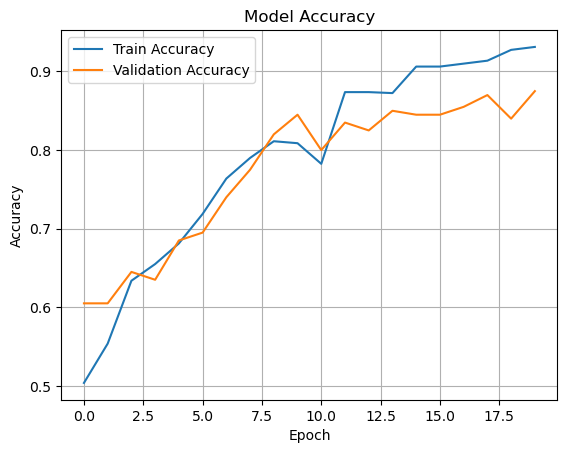

In [7]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend(); plt.grid(True)
plt.show()